In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
df = pd.read_csv("magic04.csv")

In [ ]:
df["class"] = (df["class"] == "g").astype(int)
df.head()

In [ ]:
cols = df.columns.tolist()

for label in cols[:-1]:
    # Filter data by class
    gamma_data  = df[df["class"] == 1][label]
    hadron_data = df[df["class"] == 0][label]

    plt.hist(gamma_data,  color='blue', label='Gamma',  alpha=0.7, density=True)
    plt.hist(hadron_data, color='red',  label='Hadron', alpha=0.7, density=True)

    plt.title(label)
    plt.ylabel('Probability')
    plt.xlabel(label)
    plt.legend()
    plt.show()

Train,validation,test datasets...

In [ ]:
train = df.sample(frac=0.6)
temp  = df.drop(train.index)

valid = temp.sample(frac=0.5)
test  = temp.drop(valid.index)

In [ ]:
def scale_dataset(dataframe, oversample=False):
    X = dataframe[dataframe.columns[:-1]].values
    Y = dataframe[dataframe.columns[-1]].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if oversample:
        oversampler = RandomOverSampler()
        X, Y = oversampler.fit_resample(X, Y)

    data = np.hstack((X, np.reshape(Y, (-1, 1))))
    return data, X, Y

In [ ]:
train_data, X_train, Y_train = scale_dataset(train, oversample=True)
valid_data, X_valid, Y_valid  = scale_dataset(valid)
test_data,  X_test,  Y_test   = scale_dataset(test)

In [ ]:
train = df.sample(frac=0.6)
temp = df.drop(train.index)

valid = temp.sample(frac=0.)
test = temp.drop(valid.index)

In [ ]:
print(len(train[train["class"] == 1]))
print(len(train[train["class"] == 0]))

KNN (K-nearest neighbour)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train,Y_train)

In [ ]:
y_pred = knn_model.predict(X_test)

In [ ]:
print(classification_report(Y_test,y_pred))

Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train,Y_train)

In [ ]:
y_pred = nb_model.predict(X_test)
print(classification_report(Y_test,y_pred))

Log Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train,Y_train)

In [ ]:
y_pred = lg_model.predict(X_test)
print(classification_report(Y_test,y_pred))

SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, Y_train)

In [ ]:
y_pred = svm_model.predict(X_test)
print(classification_report(Y_test,y_pred))

Neural Net

In [ ]:
import tensorflow as tf

In [ ]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary crossentropy')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_accuracy(history):
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(10,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='binary_crossentropy',
                 metrics=['accuracy'])

In [53]:
history = nn_model.fit(
    X_train, Y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0
)

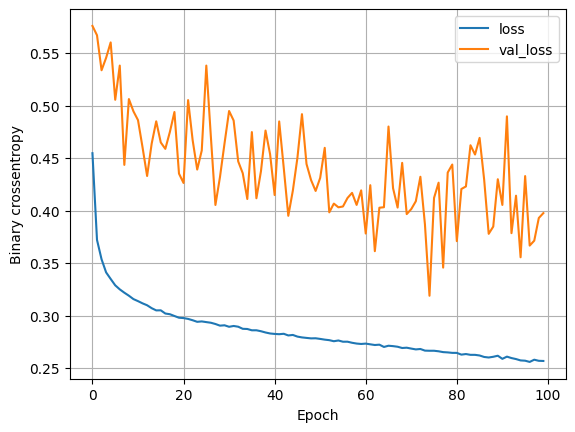

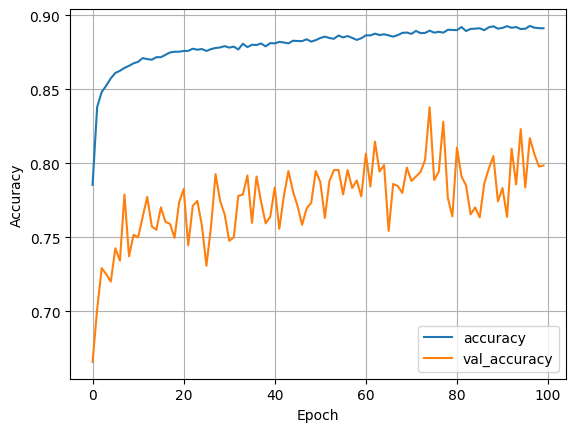

In [54]:
plot_loss(history)
plot_accuracy(history)